In [1]:
import json
import time
from openai import OpenAI
import re 
import os 
import concurrent.futures

In [ ]:
# Deepseek
client = OpenAI(
    api_key="sk-xxx", 
    base_url="https://api.deepseek.com/v1" 
) 
MODEL_NAME = "deepseek-chat" 
OUTPUT_FILE = "./ris/refined/classification_results_deepseek_2.json"


# Classification dimensions
DOMAINS = ["Software Engineering",
           "Annotation / Data Labeling", 
           "Healthy Care", 
           "Education", 
           "Robotics ",  
           "Cybersecurity",
           "Society Simulation",
           "Industry 5.0 / Smart Manufacturing", 
           "Scientific Research",
           "Other",
           "full text read needed"
           ]
     

TECHNOLOGIES = ["Multi-Agent", 
              "RAG", 
              "finetune", 
              "multimodal", 
              "Prompt Engineering", 
              "GraphRAG",
              "Model Context Protocol",
              "Tool Using",
              "Reasoning",
              "Other",
              "full text read needed"
              ]
       

INPUT_FILE = "./ris/refined/qury_res_unique_with_abstracts.ris"
MAX_CONCURRENCY = 128 

In [6]:
def parse_txt_to_records(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    records_text = re.split(r'\nER\s*-\s*\n', content.strip() + '\nER - \n')
    records = []
    
    for record_text in records_text:
        if not record_text.strip():
            continue 
        record = {}
        for line in record_text.strip().split('\n'):
            match = re.match(r'([A-Z0-9]+)\s*-\s*(.*)', line, re.DOTALL)
            if match:
                tag = match.group(1).strip()
                value = match.group(2).strip()
                
                if tag in record and tag != 'AU': 
                    record[tag] += '\n' + value
                elif tag == 'AU': 
                    if 'AU' not in record:
                        record['AU'] = []
                    record['AU'].append(value)
                else:
                    record[tag] = value
        
        if 'TI' in record and 'AB' in record:
            records.append(record)
            
    return records

In [ ]:
def construct_prompt(title, abstract):
    """Constructs the system and user prompts for LLM classification."""
    system_prompt = f"""
    you are a professional academic literature classification assistant. Please classify the literature into the following two dimensions based on its title and abstract:
    1. Application Domain: {', '.join(DOMAINS)}
    2. Technologyies Used: {', '.join(TECHNOLOGIES)},
    you can add other classification labels in "Application domain" or "Technologyies Used" if you think there are more suitable label.
    """
    
    user_prompt = f"""
    Title: {title}
    Abstract: {abstract}
    output in the following json format:
    {{
        "reasoning": "short reason in 150 words",
        "domain": "choose the most fitting domain"
        "technology": "choose the most fitting technology"
    }}
    """
    return system_prompt, user_prompt

In [5]:

def classify_single_record(record_with_index):
    """
    Performs the API call for a single record. 
    """
    record = record_with_index['record']
    index = record_with_index['index']
    
    title = record.get('TI', 'N/A')
    abstract = record.get('AB', 'N/A') 
    system_prompt, user_prompt = construct_prompt(title, abstract)
    
    classification_data = {
        "record_index": index,
        "title": title,
        "abstract": abstract, 
        "classification": {},
        "raw_response": ""
    }
    
    # print(f"-> Classification No. {index} paper: {title}")
    
    try:
        response = client.chat.completions.create(
            model=MODEL_NAME, 
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format={"type": "json_object"} 
        )
        
        raw_content = response.choices[0].message.content
        classification_data["raw_response"] = raw_content
     
        classification_data["classification"] = json.loads(raw_content)
        domain = classification_data['classification'].get('domain', 'N/A')
        technique = classification_data['classification'].get('technology', 'N/A')
        # print(f" No. {index} paper classification done: Application Domain={domain}，Technology adopted={technique}")

    except Exception as e:
        print(f" No. {index} paper Err: {e}")
        classification_data["classification"] = {
            "error": str(e),
            "domain": "Error",
            "technique": "Error"
        }
    
    return classification_data

In [16]:
# 1. Parse Input File
records = parse_txt_to_records(INPUT_FILE)
# 2. Resume Check (Handling the JSONDecodeError during reading)
start_index = 0
# List to hold ALL results (completed + new)
all_results = [] 

if os.path.exists(OUTPUT_FILE) and os.path.getsize(OUTPUT_FILE) > 0:
    with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
        all_results = json.load(f) 
        max_index = max(r.get("record_index", 0) for r in all_results)
        start_index = max_index
    print(f"Found {start_index} records completed, start from No. {start_index + 1}.")

tasks_to_run = []
for i, record in enumerate(records):
    current_index = i + 1
    if current_index > start_index:
        tasks_to_run.append({'record': record, 'index': current_index})

newly_completed_results = [] 

with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_CONCURRENCY) as executor:
    future_to_record = {
        executor.submit(classify_single_record, task): task 
        for task in tasks_to_run
    }
    
    for future in concurrent.futures.as_completed(future_to_record):
        try:
            result = future.result() 
            newly_completed_results.append(result)
            
        except Exception as e:
            record_index = future_to_record[future]['index']
            print(f" No. {record_index} paper returned an exception: {e}")

all_results.extend(newly_completed_results)
all_results.sort(key=lambda x: x.get("record_index", 0))
print(f"\n4. Finished. Saving all {len(all_results)} results to {OUTPUT_FILE}...")

with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=4)

Found 1505 records completed, start from No. 1506.

4. Finished. Saving all 1505 results to ./ris/refined/classification_results_deepseek_2.json...


Counter({'2025': 944, '2024': 388, '2026': 113, '2023': 58, '2022': 2}) <class 'collections.Counter'>


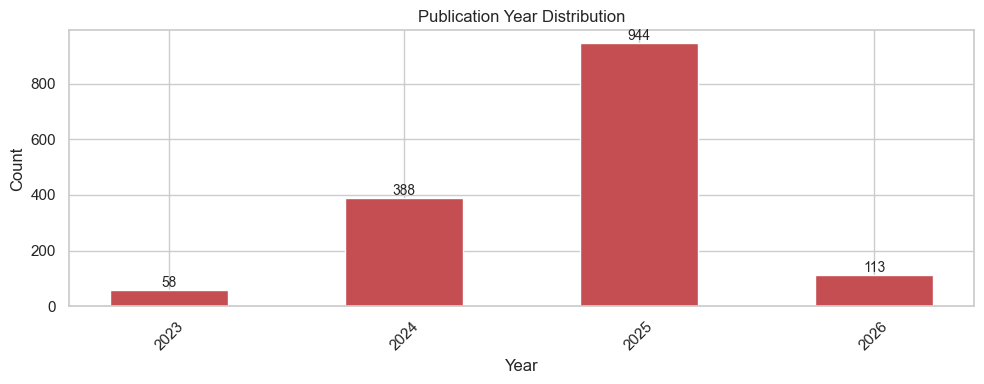

In [15]:
import re
from collections import Counter
import matplotlib.pyplot as plt

records = parse_txt_to_records(INPUT_FILE)

years_per_record = []
for r in records:
    year = None
    for tag in ('PY', 'DA'):
        if tag in r and r[tag]:
            m = re.search(r"(\d{4})", r[tag])
            if m:
                year = m.group(1)
                break
    years_per_record.append(year)


year_counter = Counter(y for y in years_per_record if y)
num_records = len(records)
num_with_year = sum(1 for y in years_per_record if y)

print(year_counter, type(year_counter))
year_counter = Counter(dict(year_counter.most_common(4)))

missing_idx = [i+1 for i,y in enumerate(years_per_record) if not y]


if year_counter:
    years_sorted = sorted(year_counter.items(), key=lambda x: int(x[0]))
    yrs = [int(y) for y,_ in years_sorted]
    counts = [c for _,c in years_sorted]

    plt.figure(figsize=(10,4))
    
    bars = plt.bar(yrs, counts, color='C3', width=0.5)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(x=bar.get_x() + bar.get_width() / 2,  
                 y=height,                             
                 s=f'{height}',                        
                 ha='center',                          
                 va='bottom',                          
                 fontsize=10)                          
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.title('Publication Year Distribution')
    plt.xticks(yrs, rotation=45)
    plt.tight_layout()
    plt.show()